# ============================================================
# NOTEBOOK 09 — SHAP EXPLAINABILITY & MODEL INTERPRETATION
# Project: Climate-Driven Solar Energy Analytics
# Model  : XGBoost  |  R² = 0.8831  |  RMSE = 0.4941
# ============================================================

"""
OBJECTIVES
----------
1. Load the trained XGBoost model from Notebook 08.
2. Build a SHAP TreeExplainer for the model.
3. Compute SHAP values on the held-out test set (2023–2024).
4. Visualise global feature importance via SHAP summary and bar plots.
5. Explore individual feature effects via dependence plots.
6. Explain single predictions via waterfall and force plots.
7. Persist all plots and provide a written interpretation.
"""

In [1]:
# ── Standard library ──────────────────────────────────────
import os
import json
import warnings
warnings.filterwarnings("ignore")

# ── Data ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Model persistence ─────────────────────────────────────
import joblib

# ── SHAP ──────────────────────────────────────────────────
import shap
print(f"SHAP version : {shap.__version__}")

# ── Visualisation ─────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
matplotlib.rcParams.update({
    "figure.dpi"      : 150,
    "font.size"       : 11,
    "axes.spines.top" : False,
    "axes.spines.right": False,
})
print(f"Matplotlib   : {matplotlib.__version__}")

# ── Paths ─────────────────────────────────────────────────
OUTPUTS_DIR = "../outputs/nb09_shap"
os.makedirs(OUTPUTS_DIR, exist_ok=True)
print(f"Output folder: {OUTPUTS_DIR}")

SHAP version : 0.51.0
Matplotlib   : 3.10.9
Output folder: ../outputs/nb09_shap


In [2]:
# ── Load meta ─────────────────────────────────────────────
with open("../outputs/nb08_meta.json") as f:
    meta = json.load(f)

FEATURE_LIST = meta["feature_list"]
print(f"Features ({len(FEATURE_LIST)}): {FEATURE_LIST}")

# ── Load XGBoost model ────────────────────────────────────
MODEL_PATH = f"../outputs/{meta['xgboost_model_file']}"   # xgboost_model.pkl
model = joblib.load(MODEL_PATH)
print(f"\nModel loaded : {MODEL_PATH}")
print(f"Model type   : {type(model).__name__}")
print(f"Best params  : {meta['best_params']}")
print(f"\nTest metrics → R²={meta['xgboost_test_r2']}  "
      f"RMSE={meta['xgboost_test_rmse']}  "
      f"MAE={meta['xgboost_test_mae']}  "
      f"MAPE={meta['xgboost_test_mape']}%")

Features (31): ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'log1p_PREC', 'WIND_CLOUD', 'MONTH_SIN', 'MONTH_COS', 'IS_MONSOON', 'DAY_OF_YEAR', 'GHI_LAG1', 'RH2M_LAG1', 'CLOUD_LAG1', 'GHI_7DAY_MEAN', 'CITY_Ahmedabad', 'CITY_Bengaluru', 'CITY_Bhopal', 'CITY_Bhubaneswar', 'CITY_Chandigarh', 'CITY_Chennai', 'CITY_Delhi', 'CITY_Guwahati', 'CITY_Hyderabad', 'CITY_Jaipur', 'CITY_Kochi', 'CITY_Kolkata', 'CITY_Mangalore', 'CITY_Mumbai', 'CITY_Pune']

Model loaded : ../outputs/xgboost_model.pkl
Model type   : XGBRegressor
Best params  : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}

Test metrics → R²=0.8831  RMSE=0.4941  MAE=0.3583  MAPE=9.71%


In [3]:
# Load train dataset

train_df = pd.read_csv(
    "../outputs/train_preprocessed.csv",
    parse_dates=["date"]
)

# Load test dataset

test_df = pd.read_csv(
    "../outputs/test_preprocessed.csv",
    parse_dates=["date"]
)

TARGET = "ALLSKY_SFC_SW_DWN"

FEATURE_LIST = meta["feature_list"]

X_train = train_df[FEATURE_LIST]
y_train = train_df[TARGET]

X_test = test_df[FEATURE_LIST]
y_test = test_df[TARGET]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

X_background = X_train.sample(
    n=min(1000, len(X_train)),
    random_state=42
)
# ── Validation ────────────────────────────────────────────
assert list(X_train.columns) == list(X_test.columns), "Train/test column mismatch"
assert list(X_test.columns) == FEATURE_LIST, "Columns don't match FEATURE_LIST"
print("Validation passed: columns match.")

# ── SHAP sample (cap at 2000 rows for speed) ──────────────
X_shap = X_test.copy()
print(f"X_shap shape : {X_shap.shape}")


Train: (21900, 31)
Test : (10965, 31)
Validation passed: columns match.
X_shap shape : (10965, 31)


In [4]:
# TreeExplainer is the native, fast explainer for XGBoost / LightGBM / CatBoost.
# It uses the model's tree structure directly — no sampling approximation needed.

explainer = shap.TreeExplainer(
    model,
    data             = X_background,   # background for interventional SHAP
    feature_perturbation = "interventional",
    model_output     = "raw"           # raw margin (log-space for regression)
)

print("TreeExplainer created successfully.")
print(f"  Expected value (base rate) : {explainer.expected_value:.4f}")

TreeExplainer created successfully.
  Expected value (base rate) : 4.2200


In [5]:
# Compute on the full test set.
# For very large test sets, subsample (e.g., 5 000 rows) for speed.

print("Computing SHAP values for test set …")
shap_values = explainer.shap_values(X_shap)                 # ndarray (n_shap, n_features)
shap_exp    = explainer(X_shap)                             # Explanation object (needed for newer plots)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Base value        : {explainer.expected_value:.4f}")

# ── Quick sanity: mean |SHAP| per feature (top 5) ─────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_LIST
).sort_values(ascending=False)

print("\nTop-5 features by mean |SHAP|:")
print(mean_abs_shap.head(5).to_string())

Computing SHAP values for test set …


100%|===================| 10949/10965 [00:16<00:00]        

SHAP values shape : (10965, 31)
Base value        : 4.2200

Top-5 features by mean |SHAP|:
log1p_PREC    0.135894
CLOUD_AMT     0.105043
WS10M         0.038211
MONTH_COS     0.024523
MONTH_SIN     0.019102


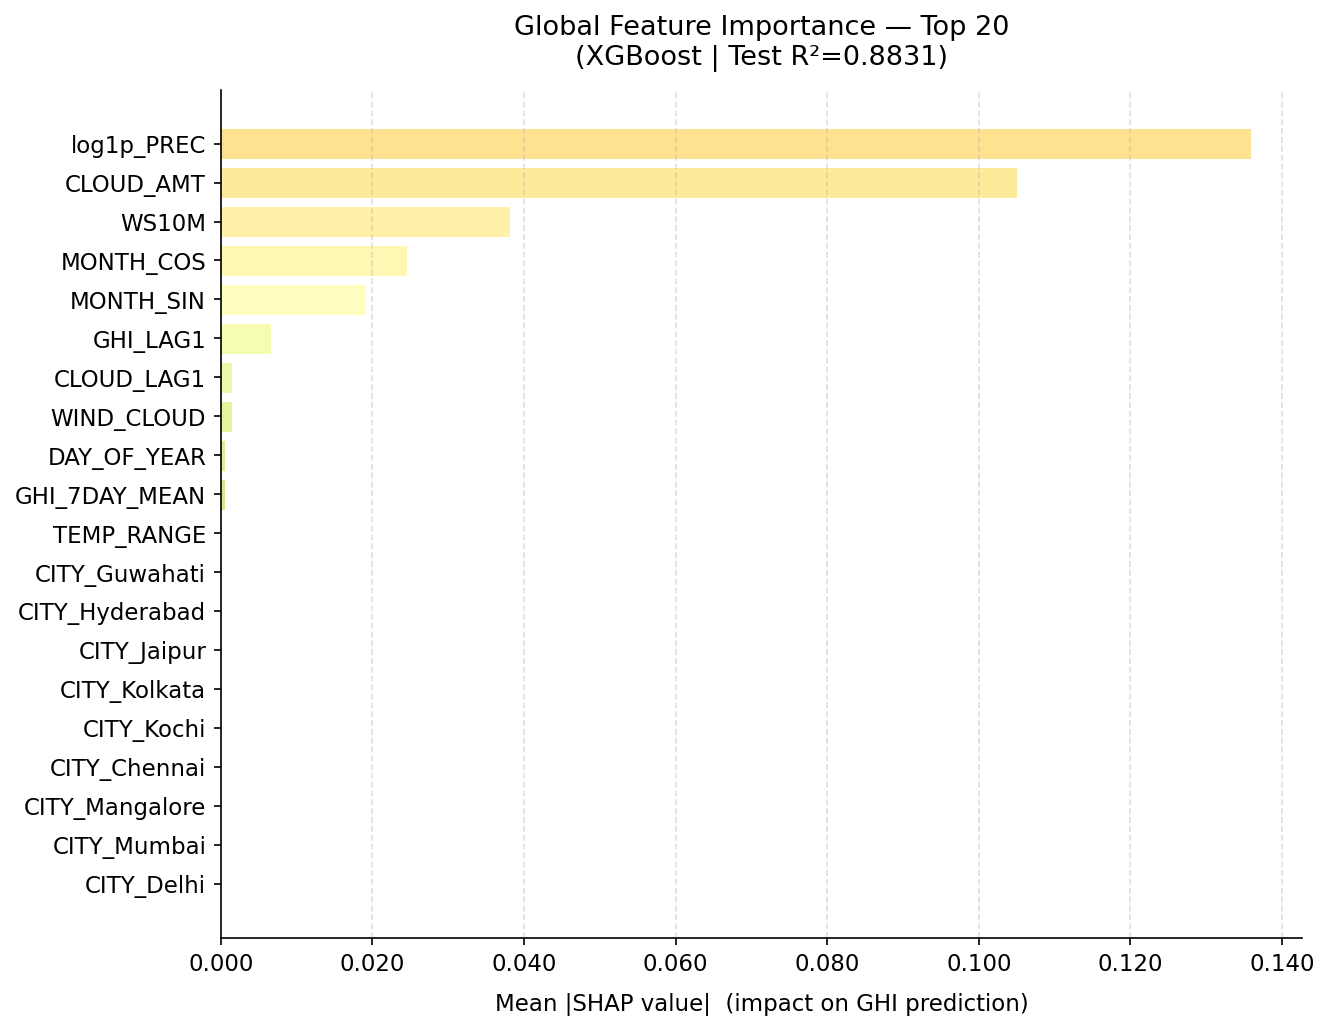

Saved → ../outputs/nb09_shap/01_global_importance_bar.png


In [6]:
# ── Custom ranked bar chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

colors = plt.cm.RdYlGn_r(
    np.linspace(0.15, 0.85, len(FEATURE_LIST))
)

top_n   = 20
top_imp = mean_abs_shap.head(top_n)

ax.barh(
    top_imp.index[::-1],
    top_imp.values[::-1],
    color=colors[:top_n],
    edgecolor="white",
    linewidth=0.5
)
ax.set_xlabel("Mean |SHAP value|  (impact on GHI prediction)", labelpad=8)
ax.set_title(
    f"Global Feature Importance — Top {top_n}\n"
    f"(XGBoost | Test R²={meta['xgboost_test_r2']})",
    fontsize=13, pad=12
)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

save_path = f"{OUTPUTS_DIR}/01_global_importance_bar.png"
fig.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

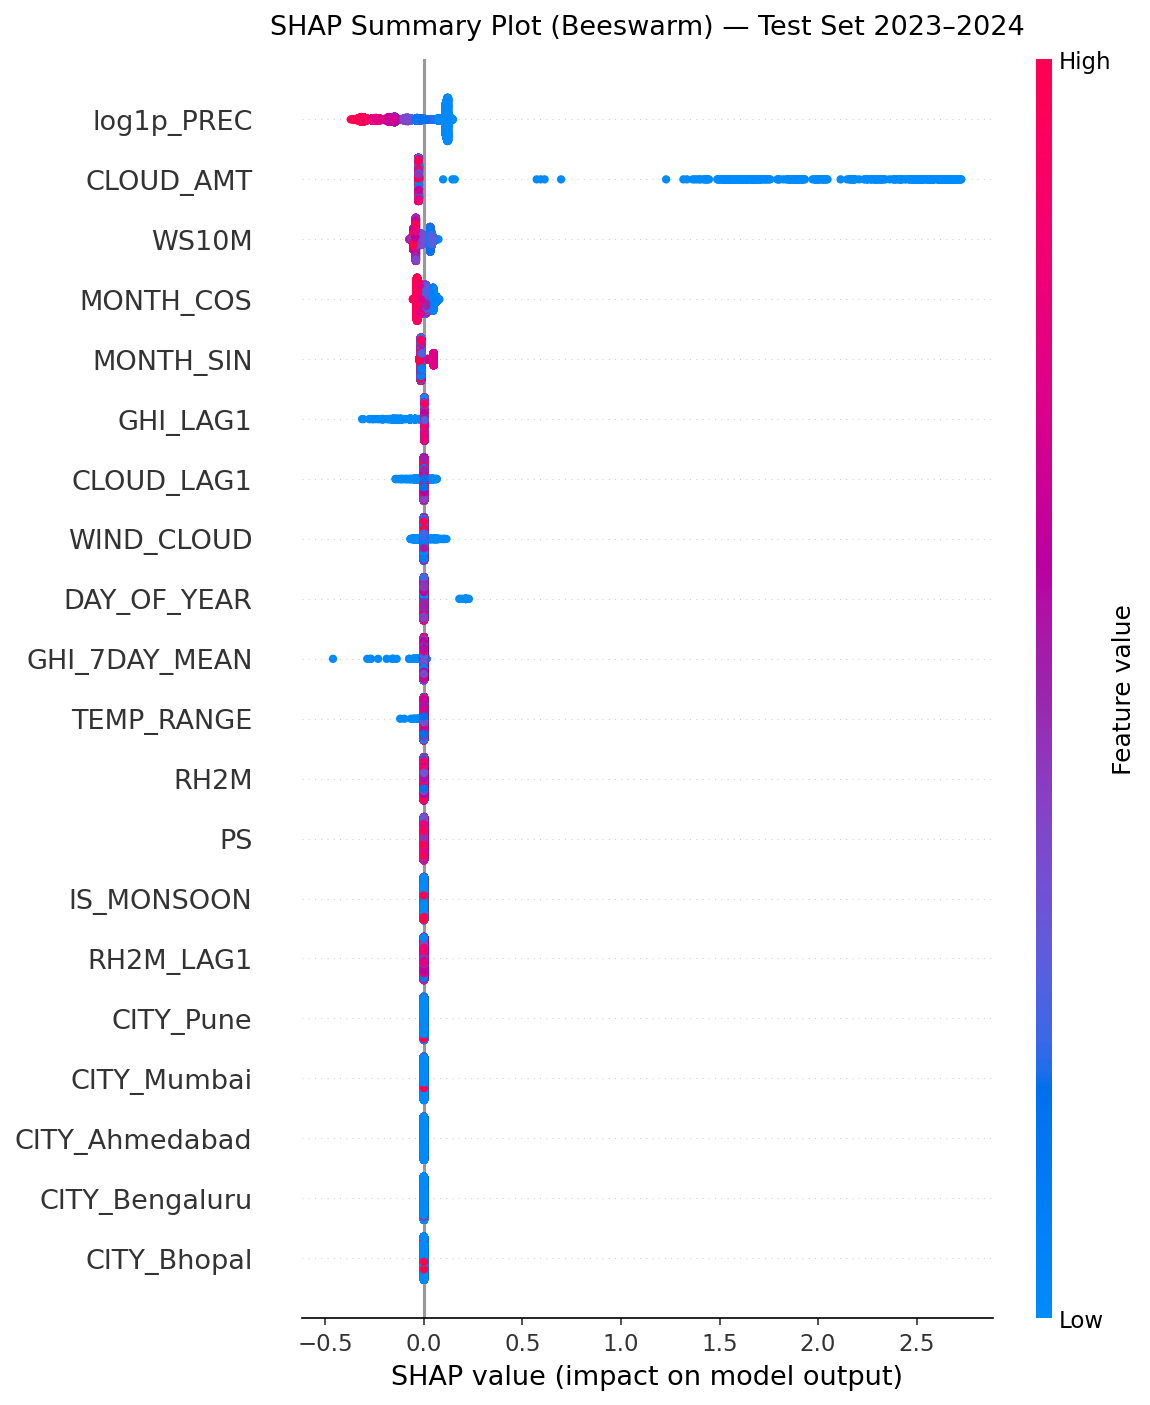

Saved → ../outputs/nb09_shap/02_shap_summary_beeswarm.png


In [7]:
# Beeswarm: each dot = one test sample.
# X-axis  = SHAP value (positive → raises GHI prediction).
# Colour  = feature value (blue=low, red=high).

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names  = FEATURE_LIST,
    plot_type      = "dot",
    max_display    = 20,
    show           = False,
    color_bar_label= "Feature value"
)
plt.title(
    "SHAP Summary Plot (Beeswarm) — Test Set 2023–2024",
    fontsize=13, pad=12
)
plt.tight_layout()

save_path = f"{OUTPUTS_DIR}/02_shap_summary_beeswarm.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

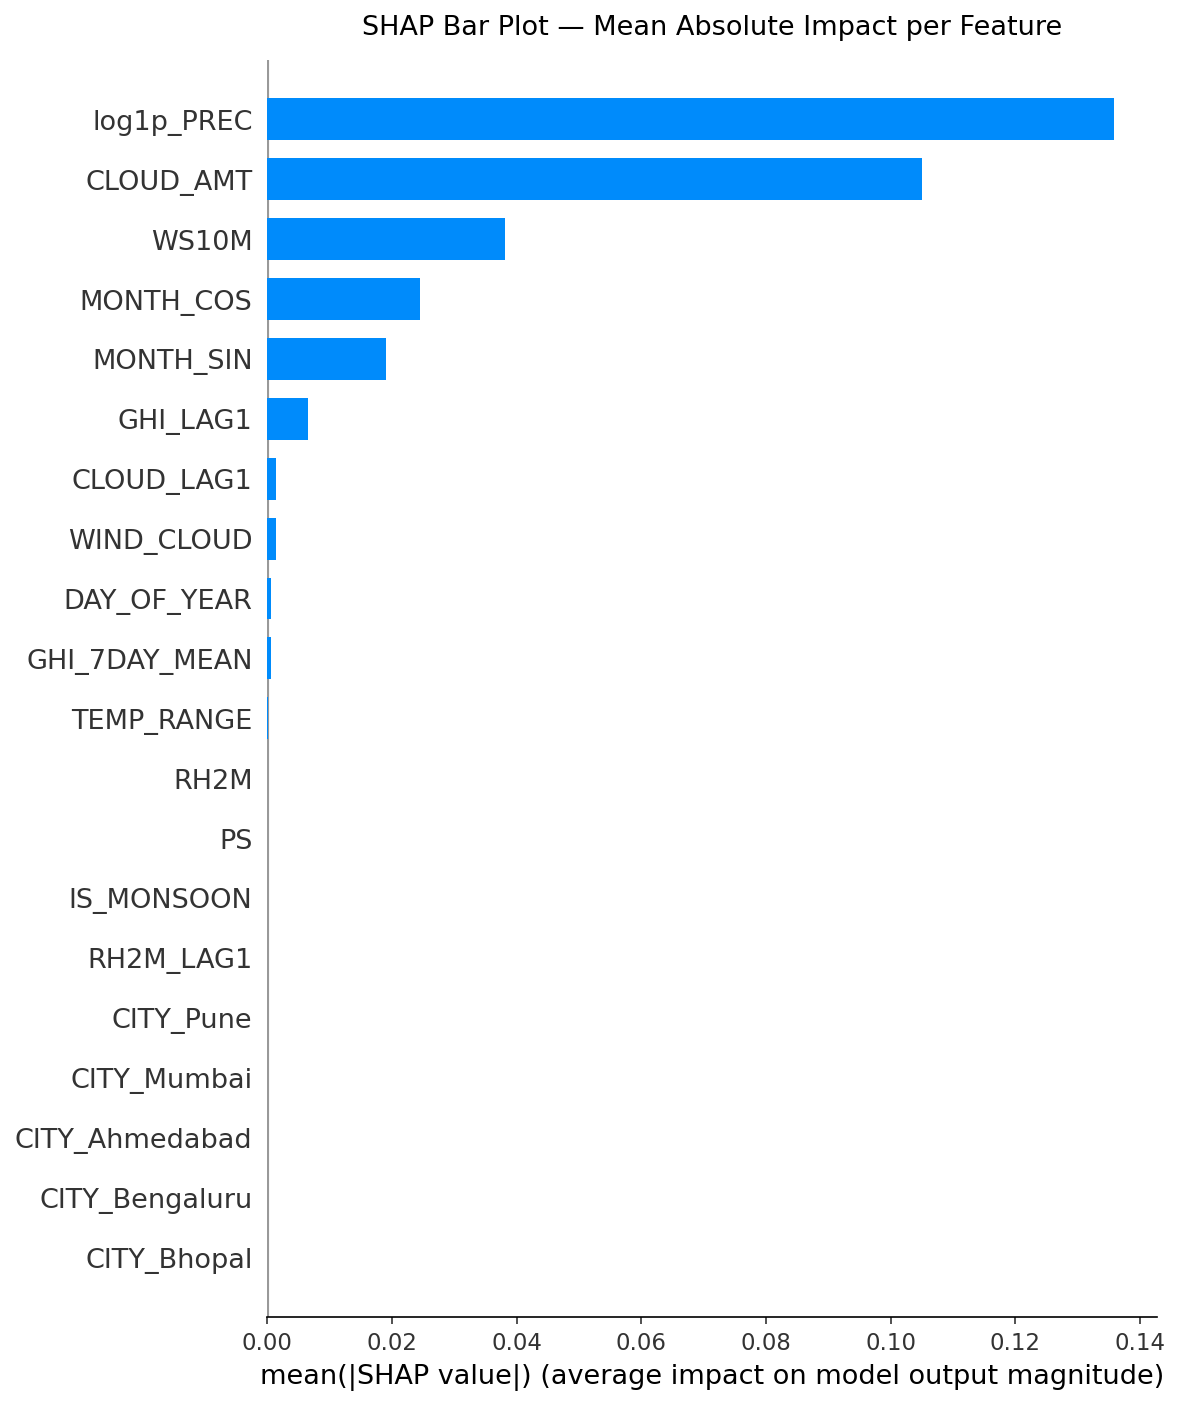

Saved → ../outputs/nb09_shap/03_shap_bar.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names = FEATURE_LIST,
    plot_type     = "bar",
    max_display   = 20,
    show          = False
)
plt.title(
    "SHAP Bar Plot — Mean Absolute Impact per Feature",
    fontsize=13, pad=12
)
plt.tight_layout()

save_path = f"{OUTPUTS_DIR}/03_shap_bar.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

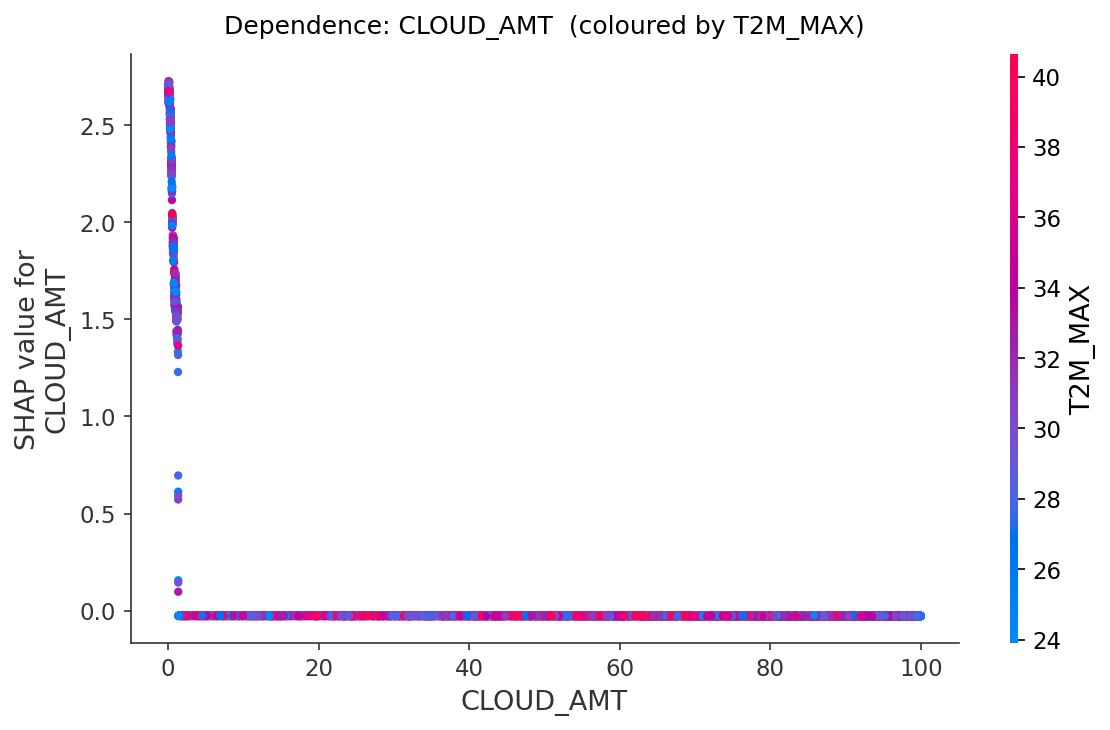

Saved → ../outputs/nb09_shap/04_dependence_CLOUD_AMT.png


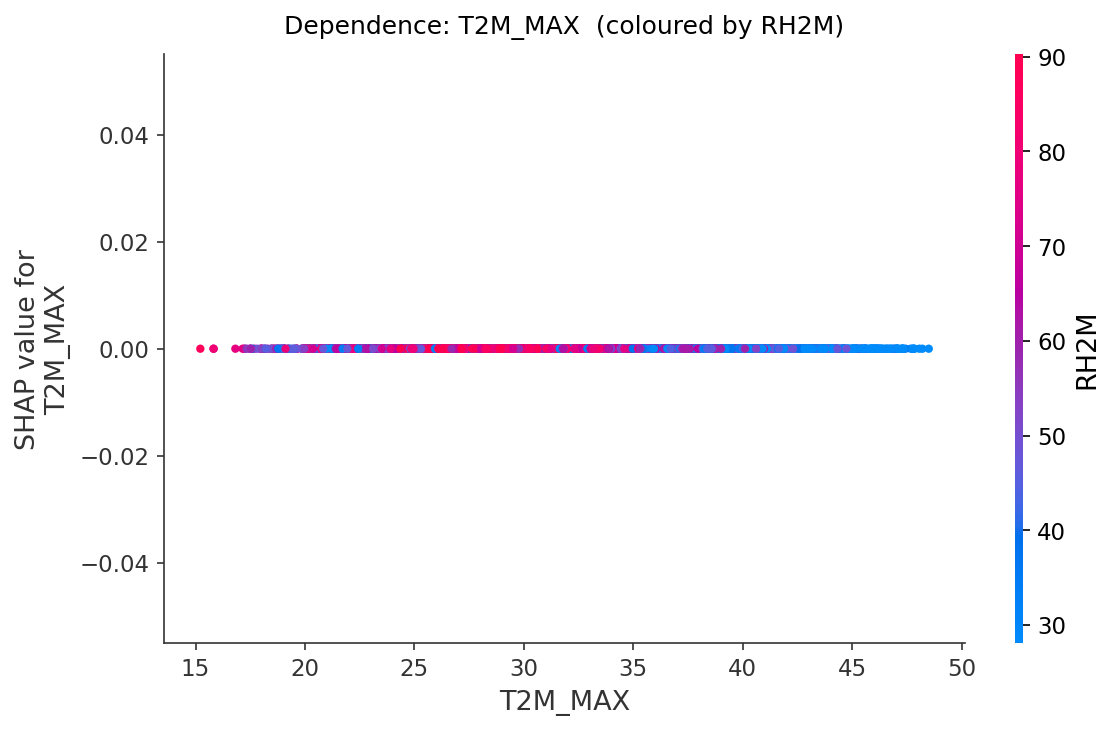

Saved → ../outputs/nb09_shap/04_dependence_T2M_MAX.png


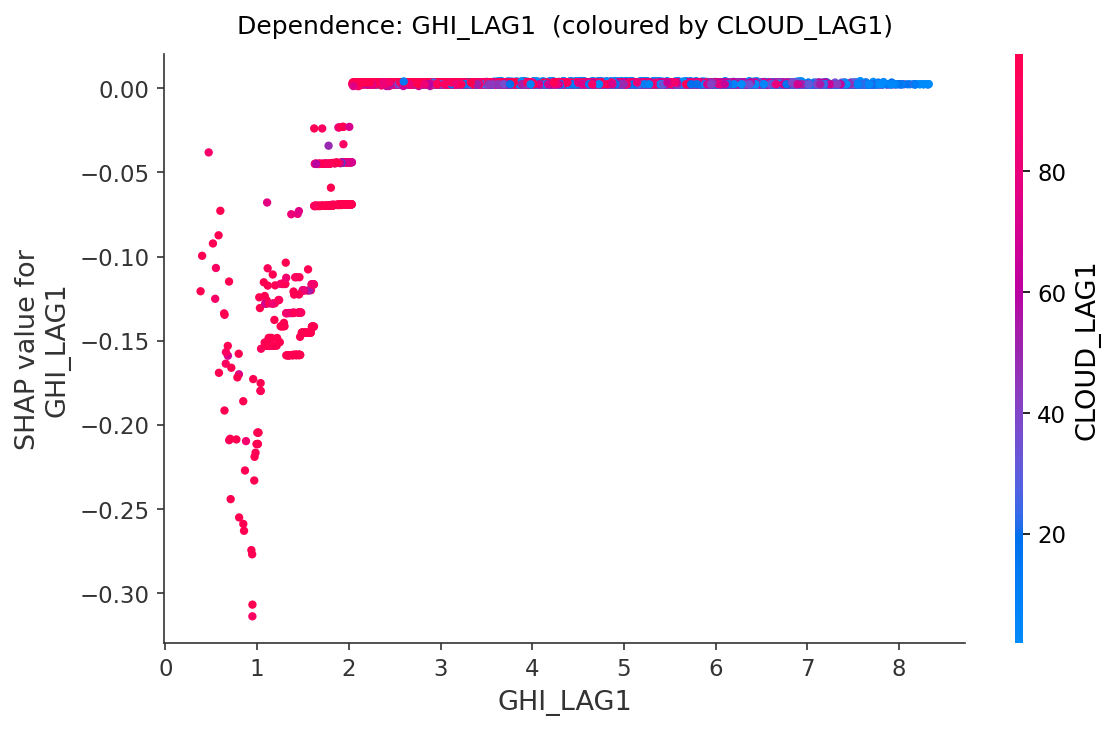

Saved → ../outputs/nb09_shap/04_dependence_GHI_LAG1.png


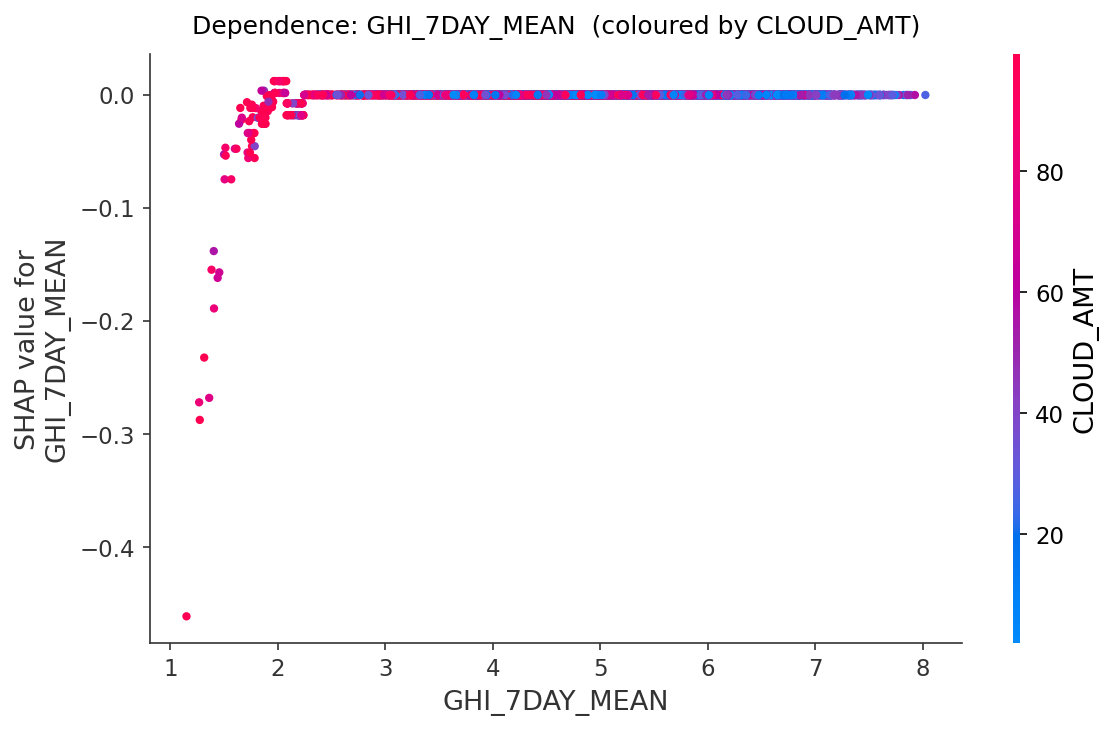

Saved → ../outputs/nb09_shap/04_dependence_GHI_7DAY_MEAN.png


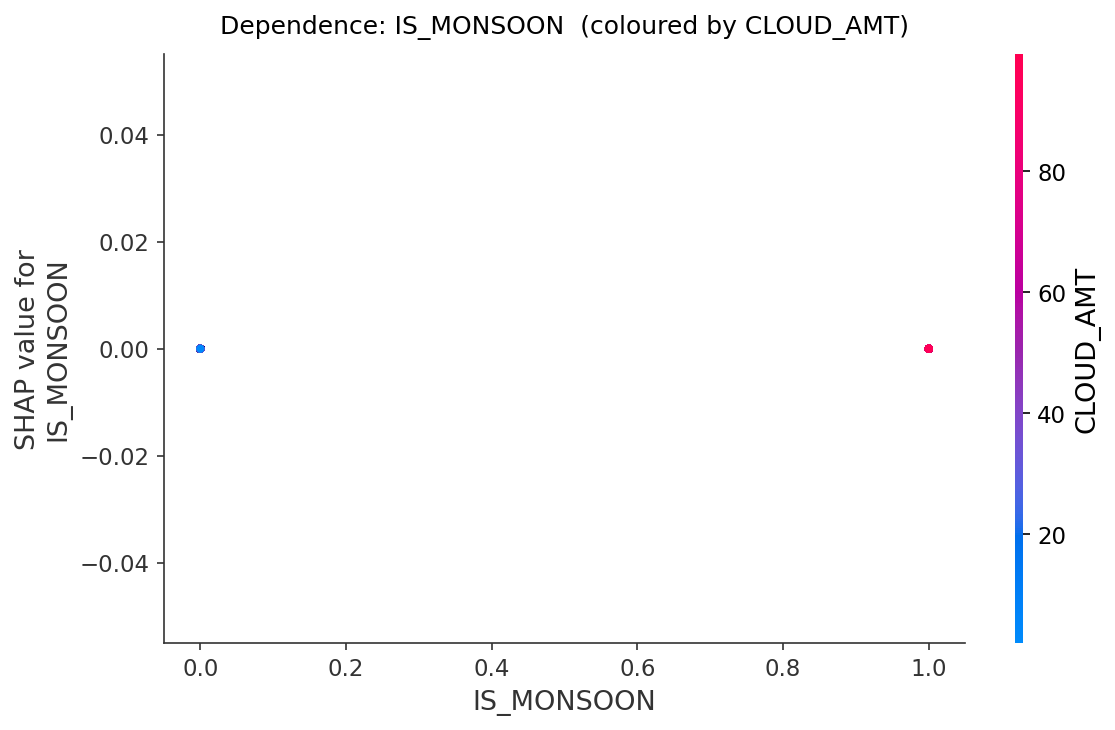

Saved → ../outputs/nb09_shap/04_dependence_IS_MONSOON.png


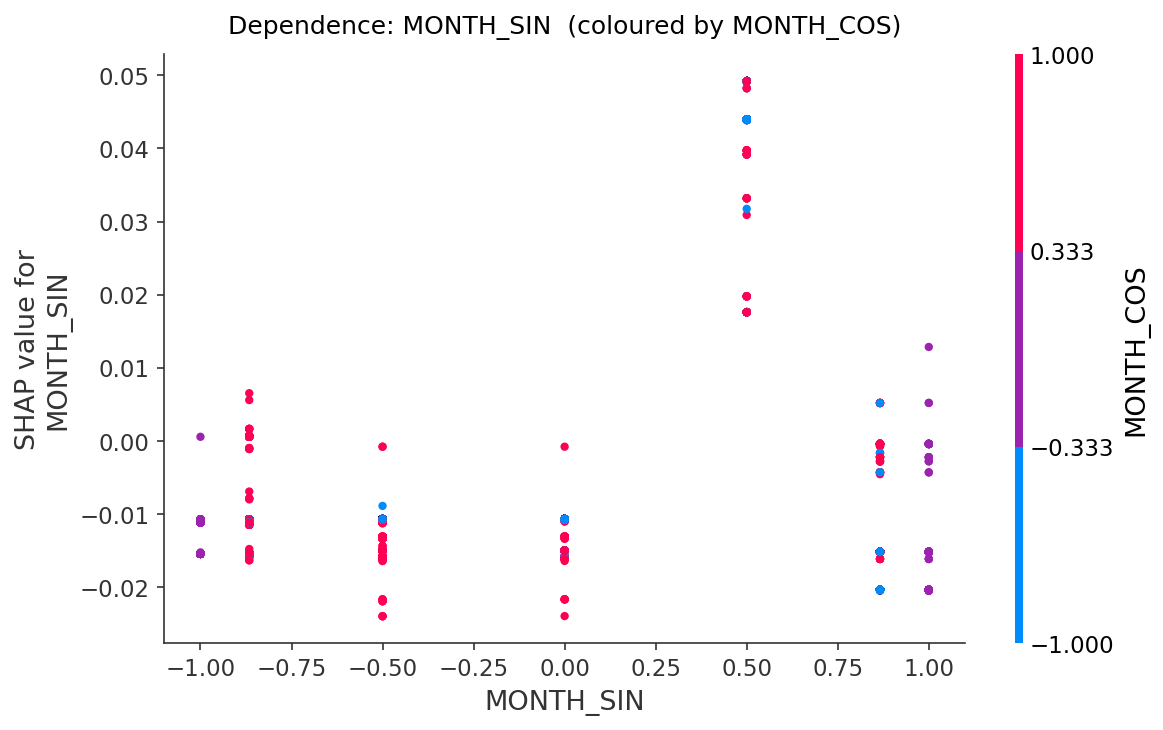

Saved → ../outputs/nb09_shap/04_dependence_MONTH_SIN.png


In [9]:
# Dependence plot: SHAP value of feature A coloured by feature B.
# The colour column is chosen automatically (highest interaction) unless set.

DEPENDENCE_PAIRS = [
    ("CLOUD_AMT",    "T2M_MAX"),
    ("T2M_MAX",      "RH2M"),
    ("GHI_LAG1",     "CLOUD_LAG1"),
    ("GHI_7DAY_MEAN","CLOUD_AMT"),
    ("IS_MONSOON",   "CLOUD_AMT"),
    ("MONTH_SIN",    "MONTH_COS"),
]

for feat, color_feat in DEPENDENCE_PAIRS:
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(
        feat,
        shap_values,
        X_shap,
        feature_names      = FEATURE_LIST,
        interaction_index  = color_feat,
        ax                 = ax,
        show               = False
    )
    ax.set_title(
        f"Dependence: {feat}  (coloured by {color_feat})",
        fontsize=12, pad=10
    )
    plt.tight_layout()

    safe_name = feat.replace("/", "_")
    save_path = f"{OUTPUTS_DIR}/04_dependence_{safe_name}.png"
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

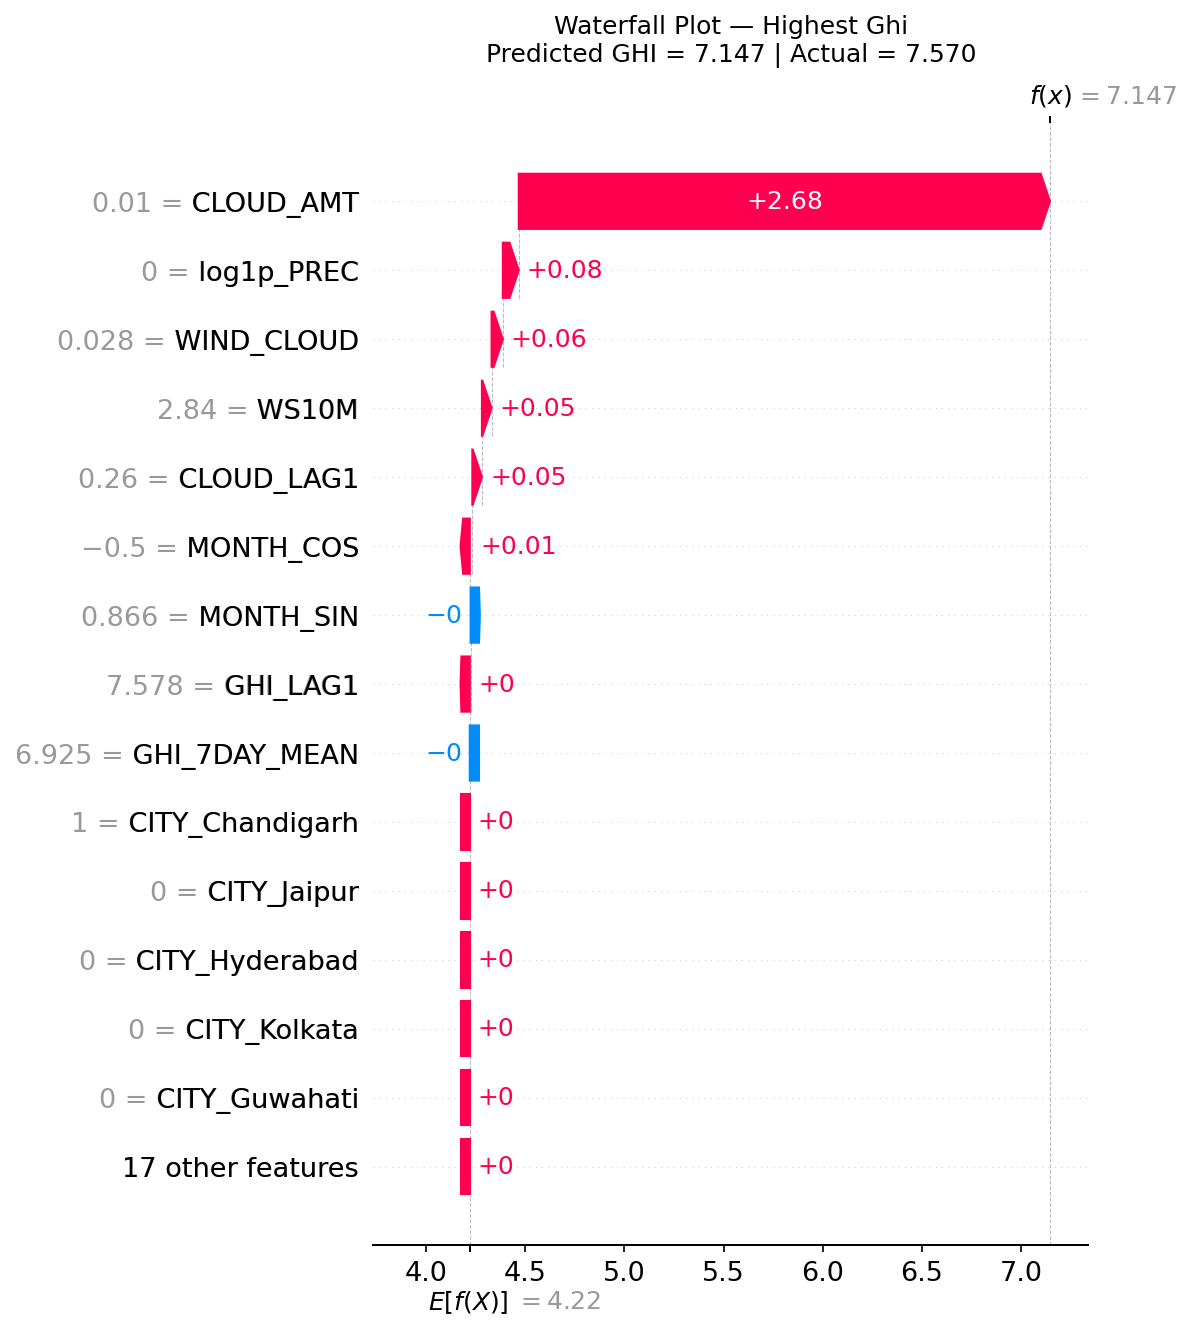

Saved → ../outputs/nb09_shap/05_waterfall_highest_GHI.png


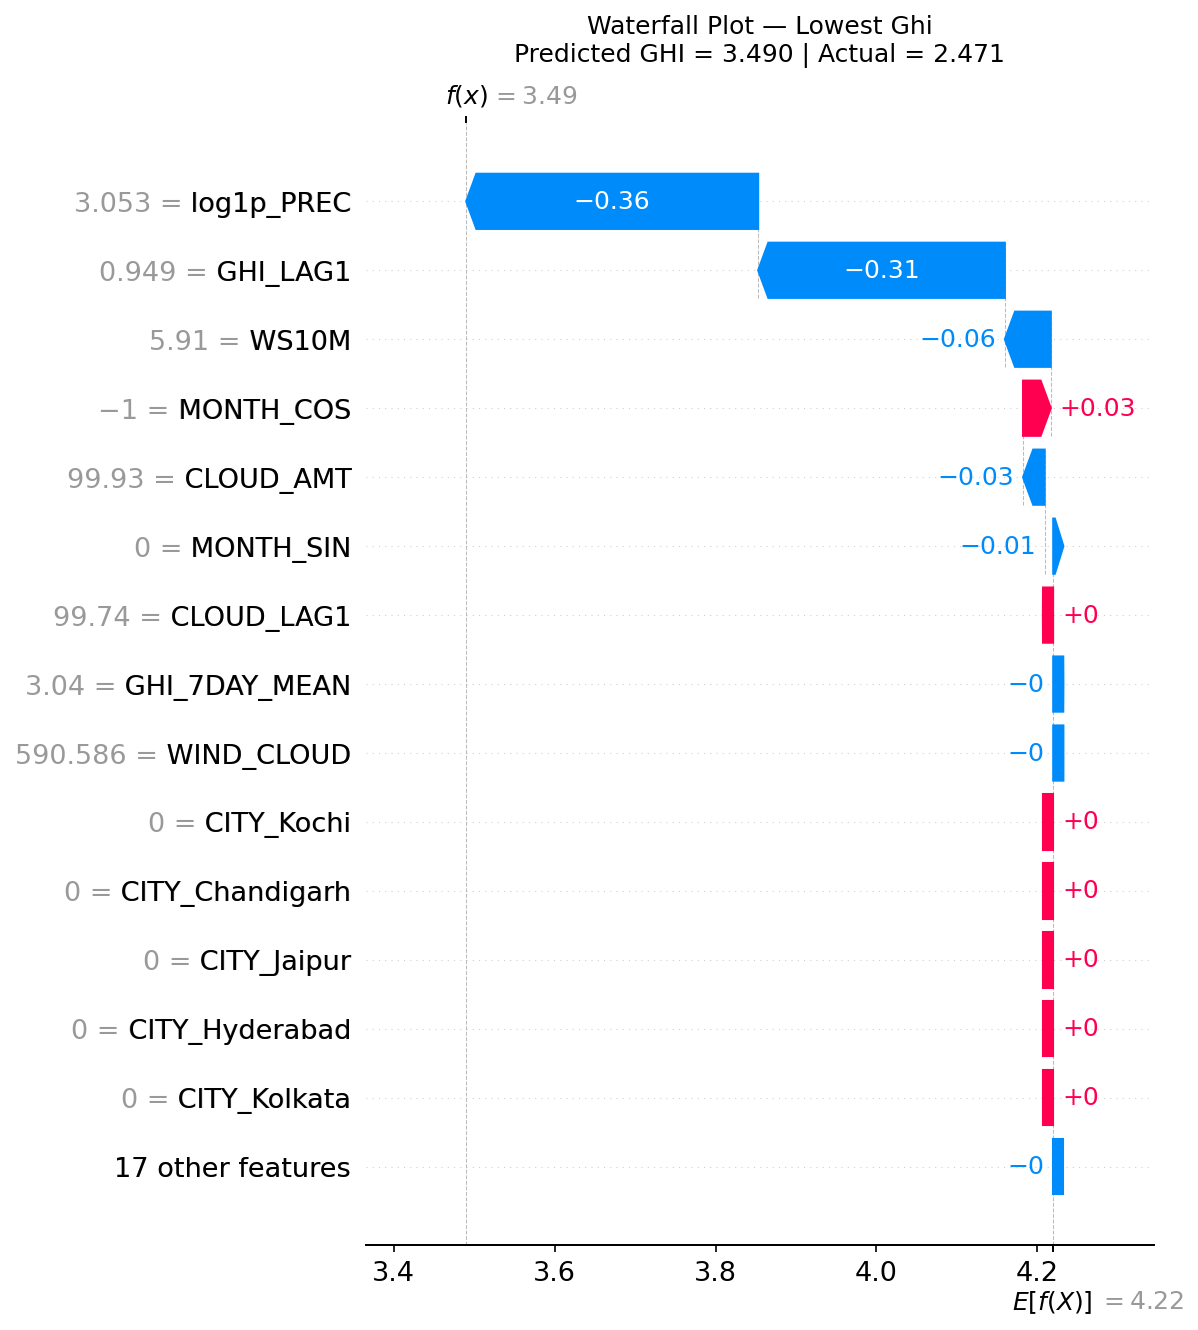

Saved → ../outputs/nb09_shap/05_waterfall_lowest_GHI.png


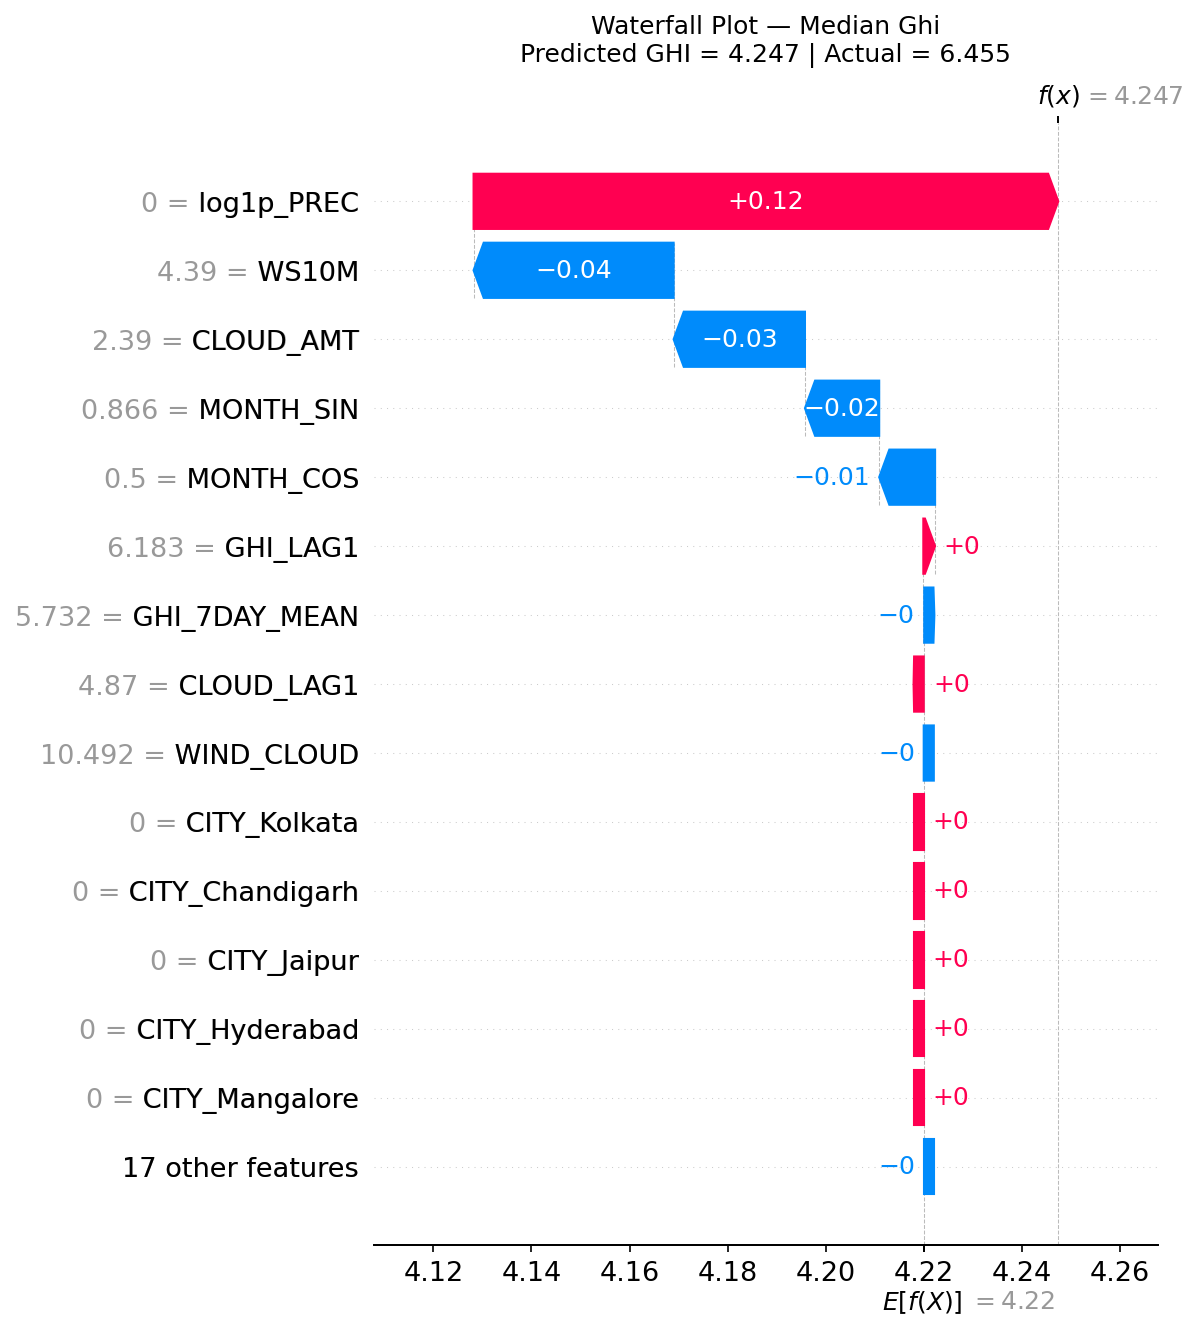

Saved → ../outputs/nb09_shap/05_waterfall_median_GHI.png


In [10]:
# Pick a handful of representative test samples for explanation.
# We use: highest GHI day, lowest GHI day, and a median day.

pred_test = model.predict(X_shap)

# Indices are relative to X_shap
idx_high   = int(np.argmax(pred_test))
idx_low    = int(np.argmin(pred_test))
idx_median = int(np.argsort(pred_test)[len(pred_test) // 2])

SAMPLE_INDICES = {
    "highest_GHI" : idx_high,
    "lowest_GHI"  : idx_low,
    "median_GHI"  : idx_median,
}

for label, idx in SAMPLE_INDICES.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[idx],
            base_values   = explainer.expected_value,
            data          = X_shap.iloc[idx].values,
            feature_names = FEATURE_LIST
        ),
        max_display = 15,
        show        = False
    )
    plt.title(
        f"Waterfall Plot — {label.replace('_',' ').title()}\n"
        f"Predicted GHI = {pred_test[idx]:.3f} | Actual = {y_test.loc[X_shap.index[idx]]:.3f}",
        fontsize=12, pad=10
    )
    plt.tight_layout()

    save_path = f"{OUTPUTS_DIR}/05_waterfall_{label}.png"
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

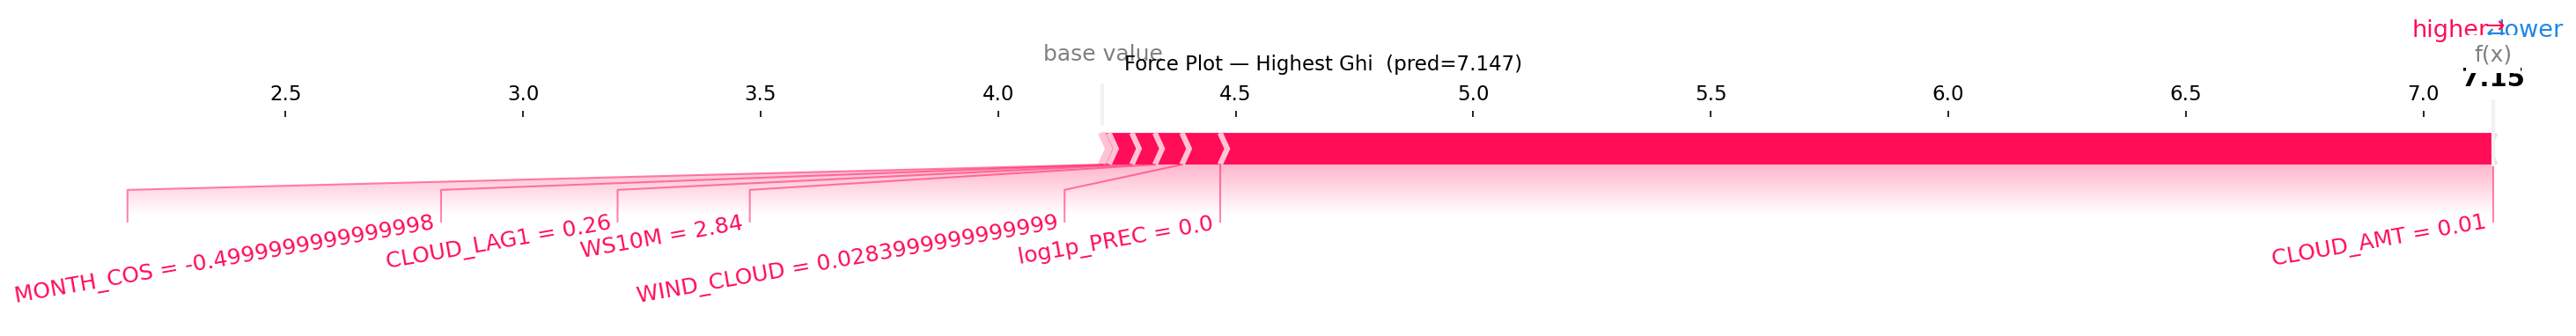

Saved → ../outputs/nb09_shap/06_force_highest_GHI.png


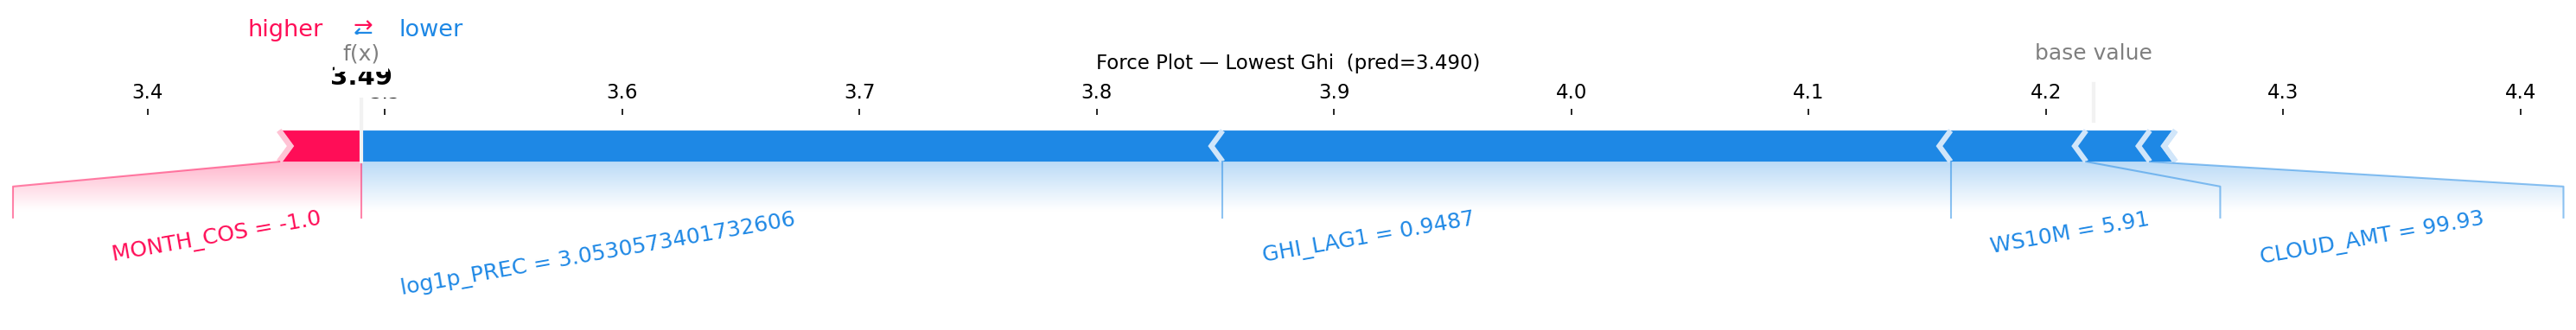

Saved → ../outputs/nb09_shap/06_force_lowest_GHI.png


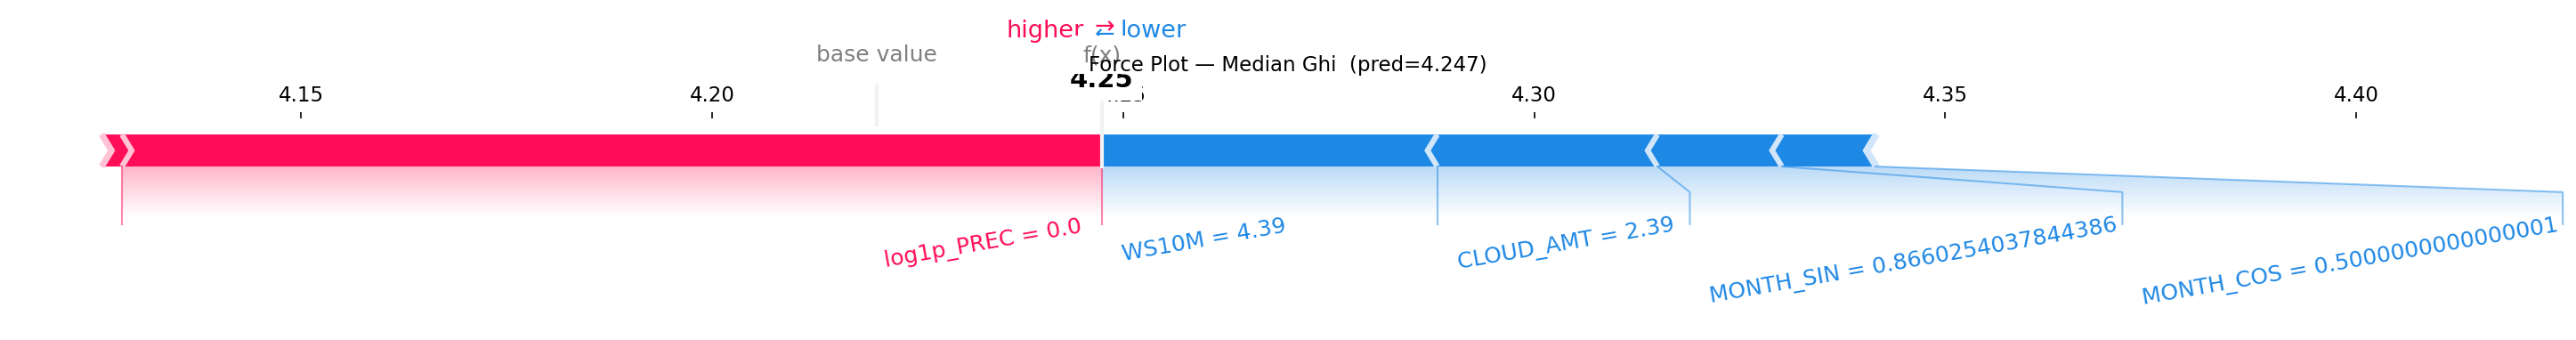

Saved → ../outputs/nb09_shap/06_force_median_GHI.png


In [11]:
# ── Static force plot for each sample (saved as PNG via matplotlib) ────
shap.initjs()   # only needed for interactive HTML — harmless in script mode

for label, idx in SAMPLE_INDICES.items():

    # Matplotlib-based force plot (works outside Jupyter too)
    force_fig = shap.force_plot(
        base_value    = explainer.expected_value,
        shap_values   = shap_values[idx],
        features      = X_shap.iloc[idx],
        feature_names = FEATURE_LIST,
        matplotlib    = True,
        show          = False,
        figsize       = (20, 3),
        text_rotation = 10
    )
    plt.title(
        f"Force Plot — {label.replace('_',' ').title()}  "
        f"(pred={pred_test[idx]:.3f})",
        fontsize=11, pad=8
    )
    plt.tight_layout()

    save_path = f"{OUTPUTS_DIR}/06_force_{label}.png"
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

# ── Optional: interactive HTML force plot for all test samples ──────
# Uncomment if running in Jupyter and want the scrollable widget:
# html_obj  = shap.force_plot(explainer.expected_value, shap_values, X_shap)
# shap.save_html(f"{OUTPUTS_DIR}/force_all_test.html", html_obj)
# print("Interactive HTML saved.")

In [12]:
import glob

saved = sorted(glob.glob(f"{OUTPUTS_DIR}/*.png"))
print(f"\n{'='*55}")
print(f"  NB09 — All plots saved to: {OUTPUTS_DIR}/")
print(f"{'='*55}")
for p in saved:
    size_kb = os.path.getsize(p) / 1024
    print(f"  {os.path.basename(p):<45} {size_kb:6.1f} KB")
print(f"{'='*55}")
print(f"  Total : {len(saved)} files")


  NB09 — All plots saved to: ../outputs/nb09_shap/
  01_global_importance_bar.png                    86.2 KB
  02_shap_summary_beeswarm.png                   126.3 KB
  03_shap_bar.png                                 84.5 KB
  04_dependence_CLOUD_AMT.png                     66.8 KB
  04_dependence_GHI_7DAY_MEAN.png                 61.2 KB
  04_dependence_GHI_LAG1.png                      70.0 KB
  04_dependence_IS_MONSOON.png                    44.0 KB
  04_dependence_MONTH_SIN.png                     55.4 KB
  04_dependence_T2M_MAX.png                       51.8 KB
  05_waterfall_highest_GHI.png                   114.6 KB
  05_waterfall_lowest_GHI.png                    115.8 KB
  05_waterfall_median_GHI.png                    114.5 KB
  06_force_highest_GHI.png                        84.7 KB
  06_force_lowest_GHI.png                         80.7 KB
  06_force_median_GHI.png                         83.8 KB
  Total : 15 files


In [13]:
print(X_shap.shape)
print(shap_values.shape)

(10965, 31)
(10965, 31)


In [14]:
print(shap_values.shape)

(10965, 31)


In [15]:
import os

for f in sorted(os.listdir("../outputs/nb09_shap")):
    print(f)

01_global_importance_bar.png
02_shap_summary_beeswarm.png
03_shap_bar.png
04_dependence_CLOUD_AMT.png
04_dependence_GHI_7DAY_MEAN.png
04_dependence_GHI_LAG1.png
04_dependence_IS_MONSOON.png
04_dependence_MONTH_SIN.png
04_dependence_T2M_MAX.png
05_waterfall_highest_GHI.png
05_waterfall_lowest_GHI.png
05_waterfall_median_GHI.png
06_force_highest_GHI.png
06_force_lowest_GHI.png
06_force_median_GHI.png


In [16]:
len(train_df)
len(test_df)

10965

In [17]:
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train rows: 21900
Test rows : 10965

Train shape: (21900, 38)
Test shape : (10965, 38)
